<a href="https://colab.research.google.com/github/codewithtrisha09/ML-LAB/blob/main/WEEK_06_COST_FUNCTIONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trisha Shetty
240962606
AIML A (2)
27/08/2026

Week 06 : Cost Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Create the following data set for Experience and Salary in CSV. Applying SLR, explore the relationship between
salary and experience with experience in x-axis and salary in y axis.
a. Check for various values of beta (slope) = 0.1, 1.5, and 0.8 with a fixed value of intercept i.e b=1.1. Plot the graph
between beta and mean squared error(MSE) for each case.
b. Try with beta between 0 to 1.5 with an increment of 0.01 keeping b (intercept) as constant and Plot the graph between
beta and mean squared error(MSE).
c. Try with different values of intercept for slope beta between 0 to 1.5 with an increment of 0.01. Plot the graph between
beta and mean squared error(MSE).
d. Use the scikit learn and compare the results of MSE

In [ ]:
salary=np.array([1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2])
experience=np.array([1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4])
df=pd.DataFrame({
    "salary":salary,
    "experience":experience
})
df.to_csv("salary_experience.csv",index=False)
print("Dataset:")
print(df)
print("\nCSV successfully Created")

Dataset:
    salary  experience
0      1.7         1.2
1      2.4         1.5
2      2.3         1.9
3      3.1         2.2
4      3.7         2.4
5      4.2         2.5
6      4.4         2.8
7      6.1         3.1
8      5.4         3.3
9      5.7         3.7
10     6.4         4.2
11     6.2         4.4

CSV successfully Created


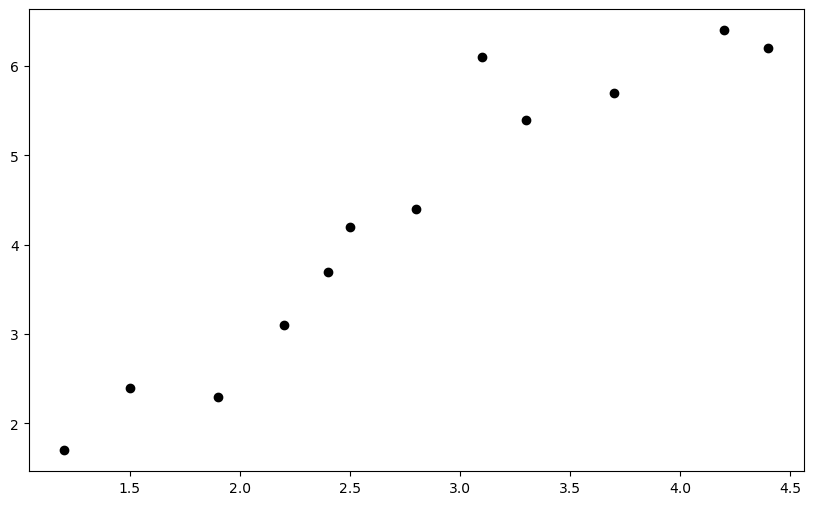

In [ ]:
data = pd.read_csv("salary_experience.csv")
X = data["experience"].values
Y = data["salary"].values
def mse(y_actual,y_predicted):
    return np.mean((y_actual-y_predicted)**2)
def predict (X,beta,b):
    return beta*X+b
betas = [0, 0.1, 0.5, 0.8]
b = 1.1
mse_values = []
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color="black", label="Actual Data")


Beta = 0
Intercept = 1.1
MSE = 12.791666666666666

Beta = 0.1
Intercept = 1.1
MSE = 10.81115

Beta = 0.5
Intercept = 1.1
MSE = 4.608750000000001

Beta = 0.8
Intercept = 1.1
MSE = 1.762599999999999


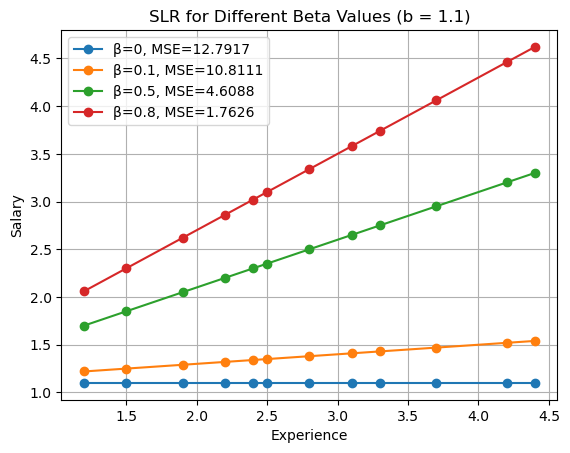

In [ ]:
for beta in betas:
    Y_pred = predict(X, beta, b)
    error = mse(Y, Y_pred)
    mse_values.append(error)

    print("\nBeta =", beta)
    print("Intercept =", b)
    print("MSE =", error)

    plt.plot(
        X, Y_pred,
        marker="o",
        label=f"β={beta}, MSE={error:.4f}"
    )

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("SLR for Different Beta Values (b = 1.1)")
plt.legend()
plt.grid(True)
plt.show()


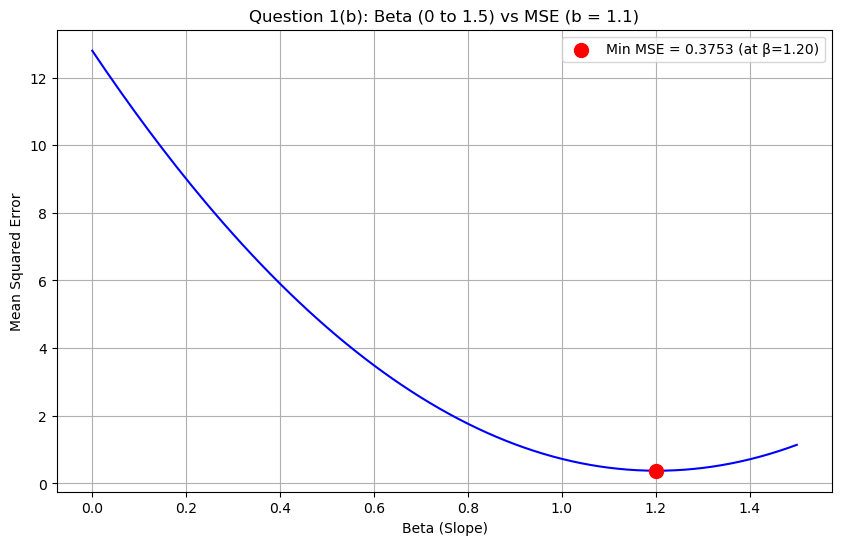

In [ ]:
beta_values_b = np.arange(0, 1.51, 0.01)
mse_beta_b = []
for beta in beta_values_b:
    Y_pred = predict(X, beta, 1.1)
    error = mse(Y, Y_pred)
    mse_beta_b.append(error)
mse_beta_b = np.array(mse_beta_b)
best_index_b = np.argmin(mse_beta_b)
best_beta_b = beta_values_b[best_index_b]
best_mse_b = mse_beta_b[best_index_b]
plt.figure(figsize=(10, 6))
plt.plot(beta_values_b, mse_beta_b, color="blue")
plt.scatter(best_beta_b,best_mse_b,color="red",s=100,zorder=5,label=f"Min MSE = {best_mse_b:.4f} (at β={best_beta_b:.2f})")
plt.xlabel("Beta (Slope)")
plt.ylabel("Mean Squared Error")
plt.title("Question 1(b): Beta (0 to 1.5) vs MSE (b = 1.1)")
plt.legend()
plt.grid(True)
plt.show()

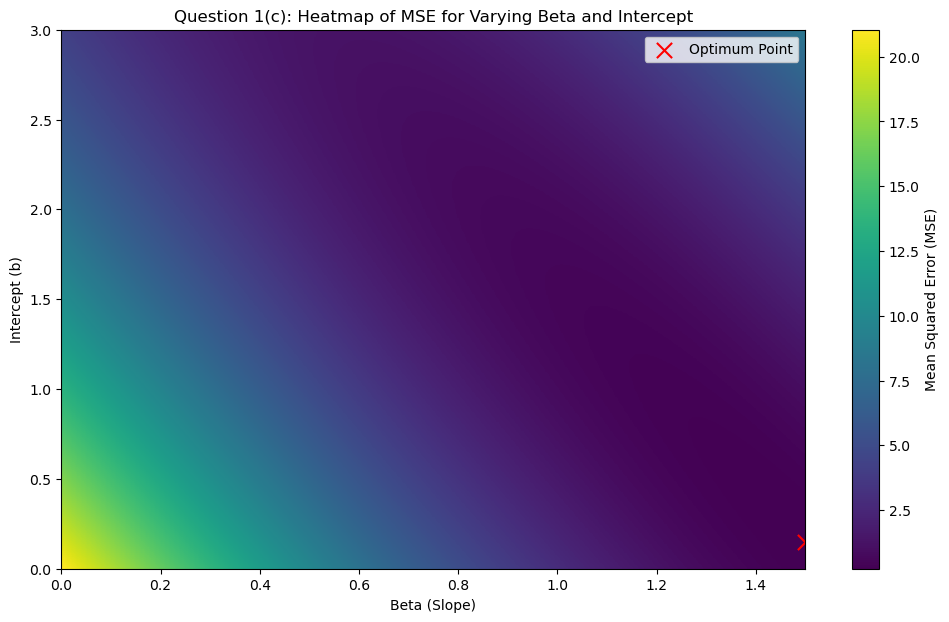

In [ ]:
beta_values_c = np.arange(0, 1.51, 0.01)
intercept_values_c = np.arange(0, 3.01, 0.01)
best_mse_c = float("inf")
best_beta_c = None
best_b_c = None
results_c = []
for b_val in intercept_values_c:
    for beta in beta_values_c:
        Y_pred = predict(X, beta, b_val)
        error = mse(Y, Y_pred)
        results_c.append([beta, b_val, error])

        if error < best_mse_c:
            best_mse_c = error
            best_beta_c = beta
            best_b_c = b_val
results_df = pd.DataFrame(results_c, columns=["Beta", "Intercept", "MSE"])
pivot_table = results_df.pivot(index="Intercept", columns="Beta", values="MSE")

plt.figure(figsize=(12, 7))
plt.imshow(
    pivot_table.values,
    aspect="auto",
    origin="lower",
    extent=[beta_values_c.min(), beta_values_c.max(), intercept_values_c.min(), intercept_values_c.max()],
    cmap="viridis"
)
plt.colorbar(label="Mean Squared Error (MSE)")
plt.scatter(best_beta_c, best_b_c, color="red", s=120, marker="x", label="Optimum Point")
plt.xlabel("Beta (Slope)")
plt.ylabel("Intercept (b)")
plt.title("Question 1(c): Heatmap of MSE for Varying Beta and Intercept")
plt.legend()
plt.show()

Analytical Beta = 1.5671
Analytical Intercept = -0.0356
Analytical MSE = 0.2337

Comparison Summary:
              Method     Beta  Intercept      MSE
Grid Search (Part C) 1.500000   0.150000 0.237917
 Analytical Solution 1.567098  -0.035639 0.233667


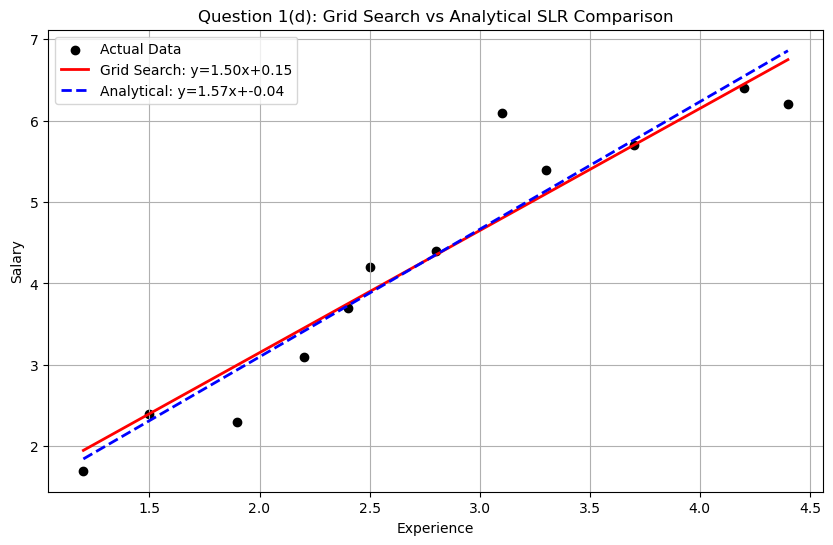

In [ ]:
x_mean = np.mean(X)
y_mean = np.mean(Y)
beta_analytical = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean) ** 2)
b_analytical = y_mean - beta_analytical * x_mean
Y_analytical = predict(X, beta_analytical, b_analytical)
mse_analytical = mse(Y, Y_analytical)
print(f"Analytical Beta = {beta_analytical:.4f}")
print(f"Analytical Intercept = {b_analytical:.4f}")
print(f"Analytical MSE = {mse_analytical:.4f}")
comparison_df = pd.DataFrame({
    "Method": ["Grid Search (Part C)", "Analytical Solution"],
    "Beta": [best_beta_c, beta_analytical],
    "Intercept": [best_b_c, b_analytical],
    "MSE": [best_mse_c, mse_analytical]
})
print("\nComparison Summary:")
print(comparison_df.to_string(index=False))
Y_best_grid = predict(X, best_beta_c, best_b_c)
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color="black", label="Actual Data")
plt.plot(X, Y_best_grid, color="red", linewidth=2, label=f"Grid Search: y={best_beta_c:.2f}x+{best_b_c:.2f}")
plt.plot(X, Y_analytical, color="blue", linestyle="--", linewidth=2, label=f"Analytical: y={beta_analytical:.2f}x+{b_analytical:.2f}")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Question 1(d): Grid Search vs Analytical SLR Comparison")
plt.legend()
plt.grid(True)
plt.show()

2.Apply Stochastic Gradient Descent for the afore-mentioned dataset, and arrive at different values of B0, B1
and error for 60 iterations of 5 epochs.
a. Plot the graph of log loss/error versus iteration.
b.Use the scikit learn and arrive at the results of B0, B1 and error, for 60 iterations of 5 epochs.
c. Plot the graph between beta (X-axis) and log loss/ error (Y-axis) using scikit learn and your approach
separately

In [ ]:
X = np.array([
    1.2, 1.5, 1.9, 2.2, 2.4, 2.5,
    2.8, 3.1, 3.3, 3.7, 4.2, 4.4
], dtype=float)
y = np.array([
    0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1
], dtype=float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))
def log_loss(y, probability):
    probability = np.clip(
        probability,
        1e-15,
        1 - 1e-15
    )
    loss = -np.mean(
        y * np.log(probability)
        +
        (1 - y) * np.log(1 - probability)
    )
    return loss

def stochastic_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    iterations=60,
    epochs=5,
    initial_b0=0,
    initial_b1=0
):

    b0 = initial_b0
    b1 = initial_b1

    history = []

    n = len(X)

    for epoch in range(epochs):

        indices = np.random.permutation(n)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for iteration in range(iterations):
            index = np.random.randint(0, n)
            xi = X_shuffled[index]
            yi = y_shuffled[index]
            z = b0 + b1 * xi
            prediction = sigmoid(z)
            error = prediction - yi
            db0 = error
            db1 = error * xi
            b0 = b0 - learning_rate * db0
            b1 = b1 - learning_rate * db1
            probabilities = sigmoid(
                b0 + b1 * X
            )

            loss = log_loss(
                y,
                probabilities
            )

            history.append({
                "Epoch": epoch + 1,
                "Iteration": iteration + 1,
                "B0": b0,
                "B1": b1,
                "Log Loss": loss
            })

    return b0, b1, pd.DataFrame(history)


In [ ]:

b0, b1, history = stochastic_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    iterations=60,
    epochs=5
)

print("Final B0 =", b0)
print("Final B1 =", b1)

final_probability = sigmoid(
    b0 + b1 * X
)

final_loss = log_loss(
    y,
    final_probability
)

print("Final Log Loss =", final_loss)
print("\nComplete SGD History")
print(history)

Final B0 = -0.2619679568867958
Final B1 = 0.28832486119120077
Final Log Loss = 0.6199289080817071

Complete SGD History
     Epoch  Iteration        B0        B1  Log Loss
0        1          1 -0.005000 -0.012000  0.698247
1        1          2  0.000144  0.010636  0.688927
2        1          3 -0.004914 -0.000494  0.693354
3        1          4  0.000103  0.020580  0.685200
4        1          5 -0.004995  0.010893  0.688792
..     ...        ...       ...       ...       ...
295      5         56 -0.256353  0.283431  0.620613
296      5         57 -0.261774  0.275299  0.619989
297      5         58 -0.258984  0.287574  0.620305
298      5         59 -0.256193  0.299297  0.620929
299      5         60 -0.261968  0.288325  0.619929

[300 rows x 5 columns]


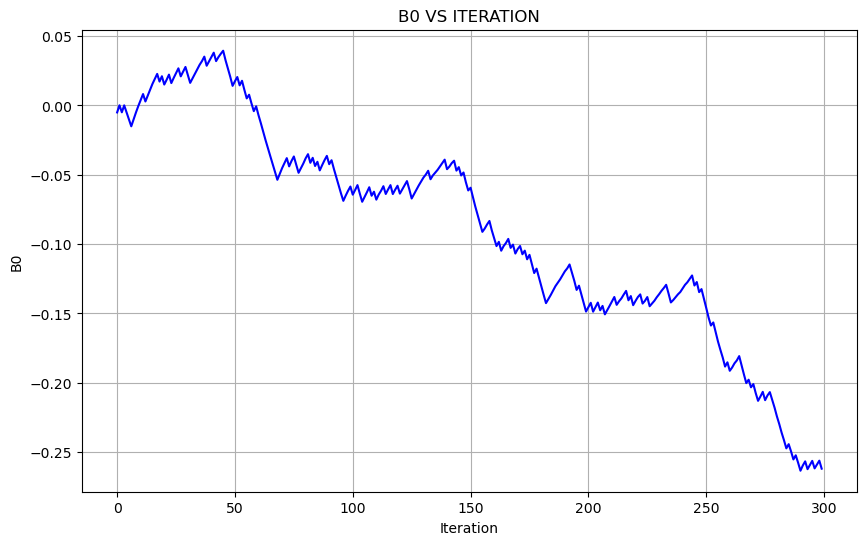

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history["B0"],color="blue")
plt.xlabel("Iteration")
plt.ylabel("B0")
plt.title("B0 VS ITERATION")
plt.grid(True)
plt.show()

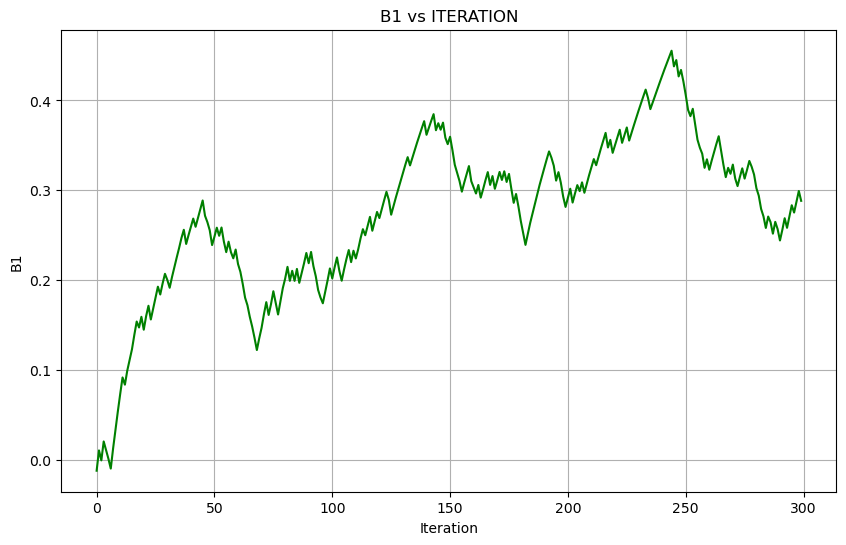

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history["B1"],color="green")
plt.xlabel("Iteration")
plt.ylabel("B1")
plt.title("B1 vs ITERATION")
plt.grid(True)
plt.show()

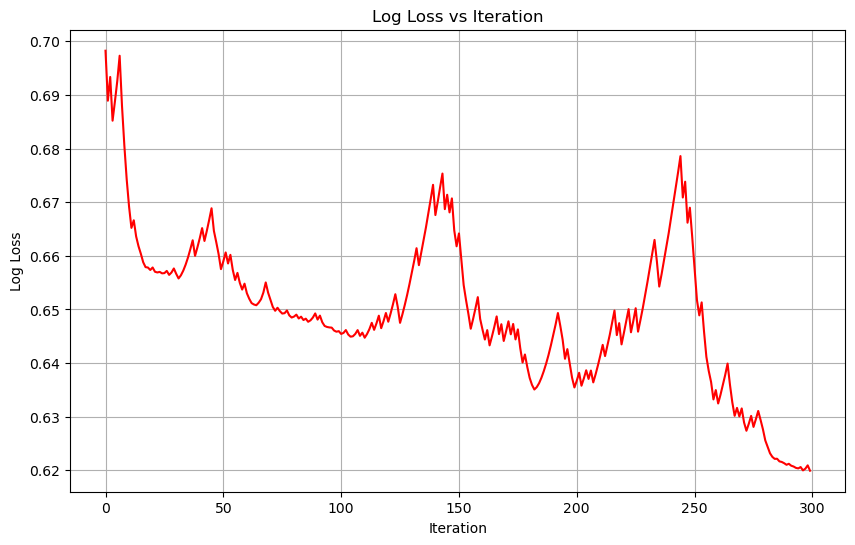

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history["Log Loss"],color="red")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Log Loss vs Iteration")
plt.grid(True)
plt.show()

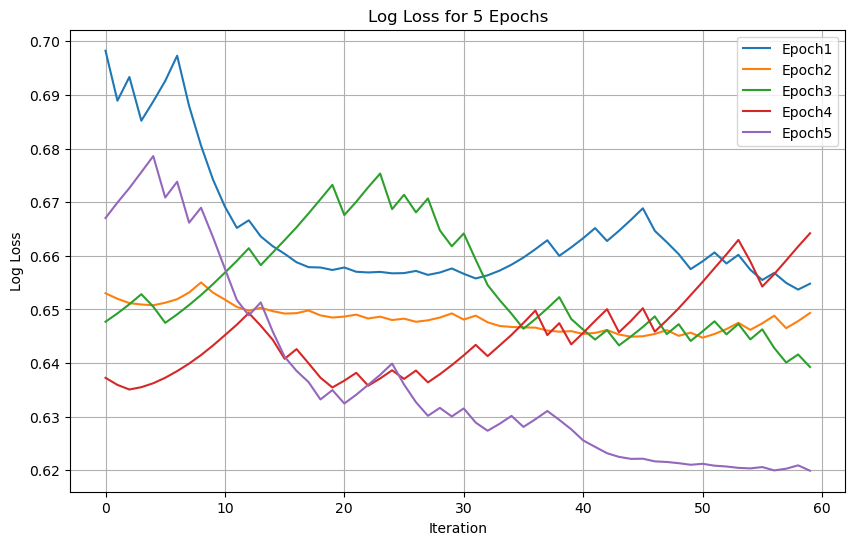

In [ ]:
plt.figure(figsize=(10,6))
for epoch in range(1,6):
    epoch_data=history[history["Epoch"]==epoch]
    plt.plot( epoch_data["Log Loss"].values,label=f"Epoch{epoch}")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Log Loss for 5 Epochs")
plt.legend()
plt.grid(True)
plt.show()

 Epoch        B0       B1  Log Loss
     1 -0.000590 0.234130  0.654807
     2 -0.057882 0.275977  0.649340
     3 -0.124003 0.282085  0.639261
     4 -0.134544 0.420267  0.664205
     5 -0.261968 0.288325  0.619929


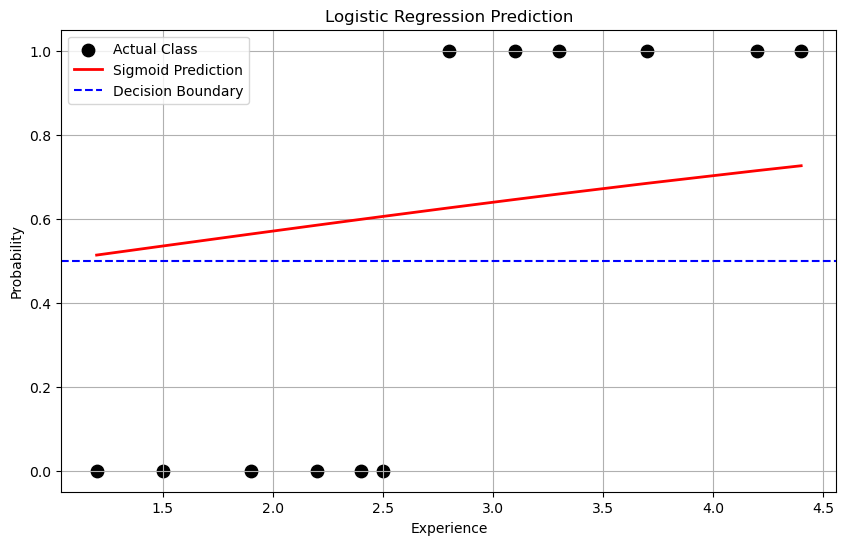

In [ ]:
epoch_summary=history.groupby("Epoch").tail(1)[["Epoch","B0","B1","Log Loss"]]
print(epoch_summary.to_string(index=False))
probabilites=sigmoid(b0+b1*X)
plt.figure(figsize=(10,6))
plt.scatter(X,y,color="black",s=80,label="Actual Class")
sort_index = np.argsort(X)
plt.plot(X[sort_index],probabilities[sort_index],color="red",linewidth=2,label="Sigmoid Prediction")
plt.axhline( 0.5,color="blue",linestyle="--",label="Decision Boundary")
plt.xlabel("Experience")
plt.ylabel("Probability")
plt.title("Logistic Regression Prediction")
plt.legend()
plt.grid(True)
plt.show()

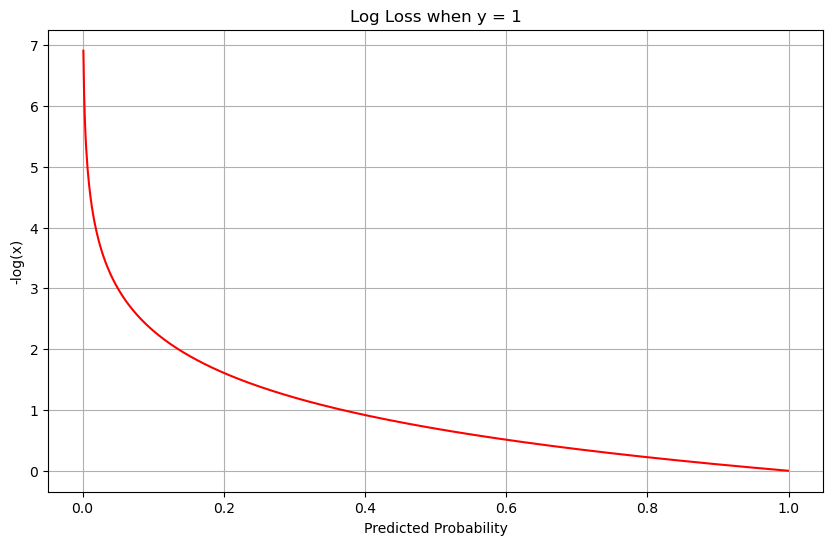

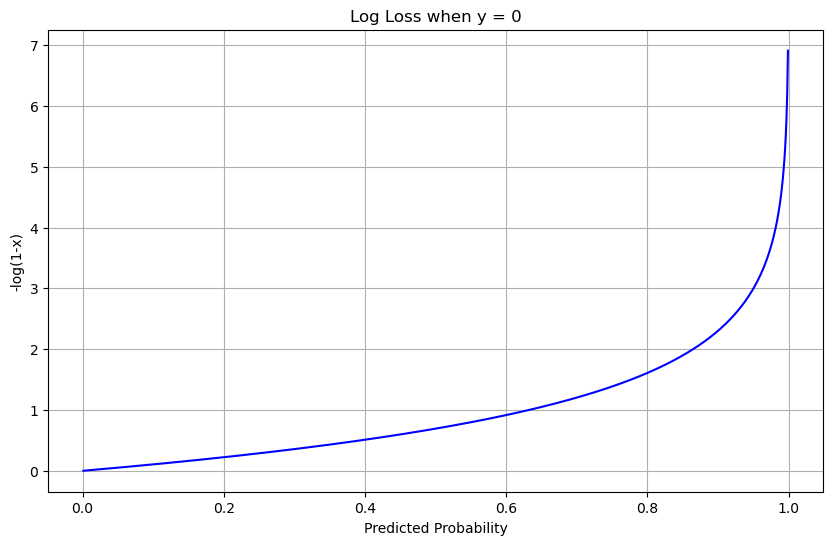

In [ ]:
probability_values=np.linspace(0.001,0.999,1000)
loss_y1=-np.log(probability_values)
loss_y0=-np.log(1-probability_values)
plt.figure(figsize=(10,6))
plt.plot(probability_values,loss_y1,color="red")

plt.xlabel("Predicted Probability")
plt.ylabel("-log(x)")
plt.title("Log Loss when y = 1")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(
    probability_values,
    loss_y0,
    color="blue"
)

plt.xlabel("Predicted Probability")
plt.ylabel("-log(1-x)")
plt.title("Log Loss when y = 0")
plt.grid(True)
plt.show()

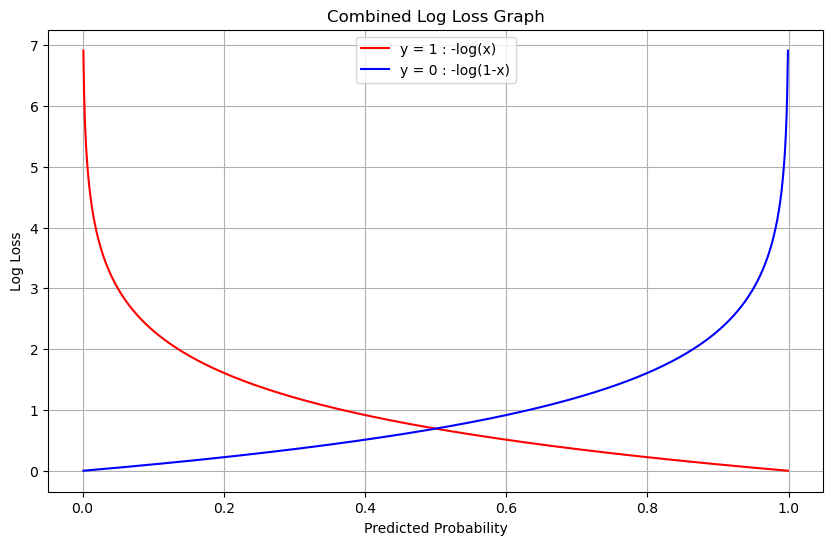

Accuracy = 0.5


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(probability_values,loss_y1,color="red",label="y = 1 : -log(x)")
plt.plot(probability_values,loss_y0,color="blue",label="y = 0 : -log(1-x)")
plt.xlabel("Predicted Probability")
plt.ylabel("Log Loss")
plt.title("Combined Log Loss Graph")
plt.legend()
plt.grid(True)
plt.show()
predicted_class = (probabilities >= 0.5).astype(int)
TP = np.sum((y == 1) & (predicted_class == 1))
TN = np.sum((y == 0) & (predicted_class == 0))
FP = np.sum((y == 0) & (predicted_class == 1))
FN = np.sum((y == 1) & (predicted_class == 0))
accuracy = (TP + TN) / len(y)
print("Accuracy =", accuracy)






3.Consider positive and negative slope dataset given below. Apply simple linear regression with gradient
descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph
of slope(x-axis) vs MSE (y-axis) for both case separately.
x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5]) # Positive slope
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 8, 6, 4, 2]) # Negative slope

Positive Slope Dataset Results 
Final Beta (Slope): 0.8401, Final Intercept: 0.2553

Negative Slope Dataset Results
Final Beta (Slope): 0.8197, Final Intercept: 1.8201

Iteration Progress Comparison (Beta Values)
Iteration  | Positive Slope Beta  | Negative Slope Beta 
-------------------------------------------------------
1          | 0.0000               | 0.0000              
5          | 0.7795               | 1.0484              
10         | 0.8405               | 1.0343              
15         | 0.8416               | 0.9367              
20         | 0.8403               | 0.8389              


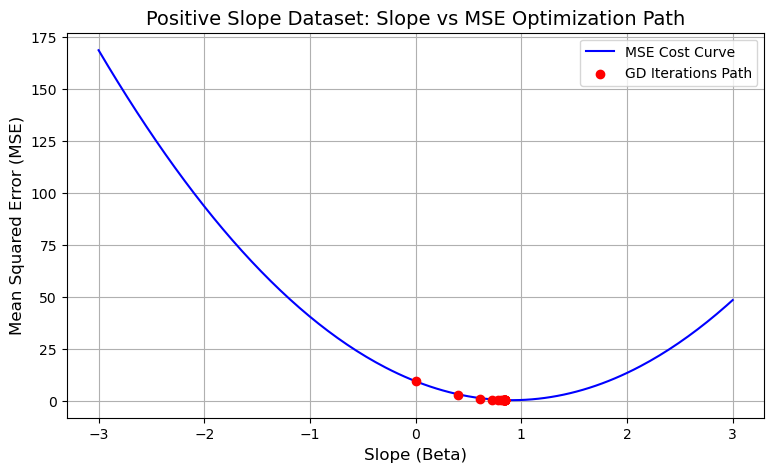

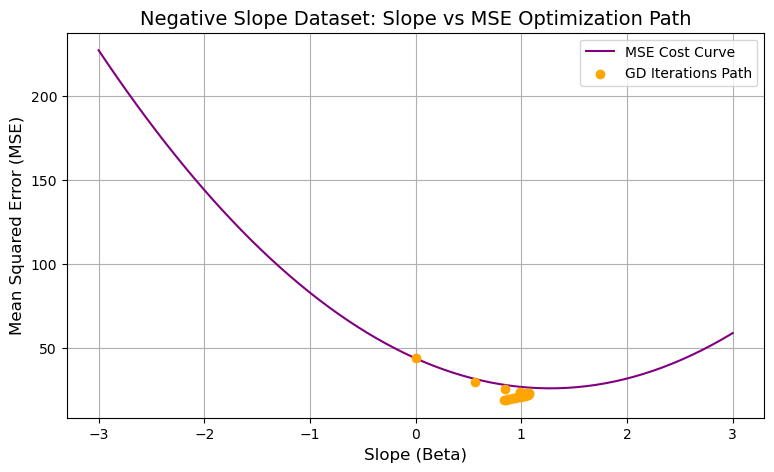

In [ ]:

x_pos = np.array([1, 2, 4, 3, 5], dtype=float)
y_pos = np.array([1, 3, 3, 2, 5], dtype=float)
x_neg = np.array([1, 2, 3, 4, 5], dtype=float)
y_neg = np.array([10, 8, 6, 4, 2], dtype=float)
def gradient_descent_slr(x, y, learning_rate=0.01, iterations=20, initial_beta=0.0):
    n = len(x)
    beta = initial_beta
    b = 0.0
    beta_history = []
    mse_history = []
    for i in range(iterations):
        y_pred = beta * x + b
        mse = np.mean((y - y_pred) ** 2)
        beta_history.append(beta)
        mse_history.append(mse)
        d_beta = (-2/n) * np.sum(x * (y - y_pred))
        d_b = (-2/n) * np.sum(y - y_pred)
        beta -= learning_rate * d_beta
        b -= learning_rate * d_b

    return beta, b, beta_history, mse_history

iterations = 20
lr = 0.02
beta_pos_final, b_pos_final, beta_pos_hist, mse_pos_hist = gradient_descent_slr(x_pos, y_pos, lr, iterations, initial_beta=0.0)
beta_neg_final, b_neg_final, beta_neg_hist, mse_neg_hist = gradient_descent_slr(x_neg, y_neg, lr, iterations, initial_beta=0.0)
print("Positive Slope Dataset Results ")
print(f"Final Beta (Slope): {beta_pos_final:.4f}, Final Intercept: {b_pos_final:.4f}")
print("\nNegative Slope Dataset Results" )
print(f"Final Beta (Slope): {beta_neg_final:.4f}, Final Intercept: {b_neg_final:.4f}")
print("\nIteration Progress Comparison (Beta Values)")
print(f"{'Iteration':<10} | {'Positive Slope Beta':<20} | {'Negative Slope Beta':<20}")
print("-------------------------------------------------------")
for idx in [0, 4, 9, 14, 19]:
    print(f"{idx+1:<10} | {beta_pos_hist[idx]:<20.4f} | {beta_neg_hist[idx]:<20.4f}")
slope_range = np.linspace(-3, 3, 200)

def compute_mse_curve(x, y, slopes):
    return [np.mean((y - (s * x)) ** 2) for s in slopes]

mse_curve_pos = compute_mse_curve(x_pos, y_pos, slope_range)
mse_curve_neg = compute_mse_curve(x_neg, y_neg, slope_range)

plt.figure(figsize=(9, 5))
plt.plot(slope_range, mse_curve_pos, color='blue', label='MSE Cost Curve')
plt.scatter(beta_pos_hist, mse_pos_hist, color='red', zorder=5, label='GD Iterations Path')
plt.xlabel("Slope (Beta)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("Positive Slope Dataset: Slope vs MSE Optimization Path", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(9, 5))
plt.plot(slope_range, mse_curve_neg, color='purple', label='MSE Cost Curve')
plt.scatter(beta_neg_hist, mse_neg_hist, color='orange', zorder=5, label='GD Iterations Path')
plt.xlabel("Slope (Beta)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("Negative Slope Dataset: Slope vs MSE Optimization Path", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

4.Consider positive and negative slope dataset given below. Apply logistic regression with gradient descent and
illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope(x-
axis) vs log-loss (y-axis) for both case separately.
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1]) # Positive slope
x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 1, 0, 0, 0]) # Negative slope

Positive Slope Dataset Results
Final Beta (Slope): 0.7256, Final Intercept: -1.1230

Negative Slope Dataset Results
Final Beta (Slope): -0.7256, Final Intercept: 1.1230

Iteration Progress Comparison (Beta Values)
Iteration   Positive Slope Beta   Negative Slope Beta 
------------------------------------------------------------------
1           0.0000                0.0000              
5           0.4274                -0.4274             
10          0.5273                -0.5273             
15          0.6211                -0.6211             
20          0.7087                -0.7087             


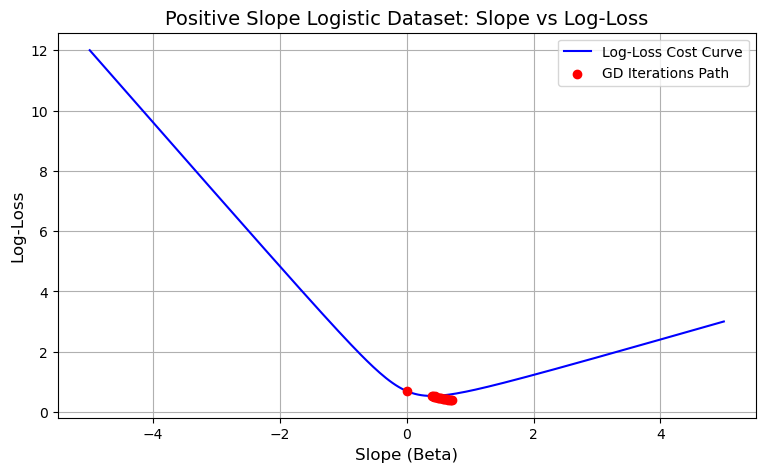

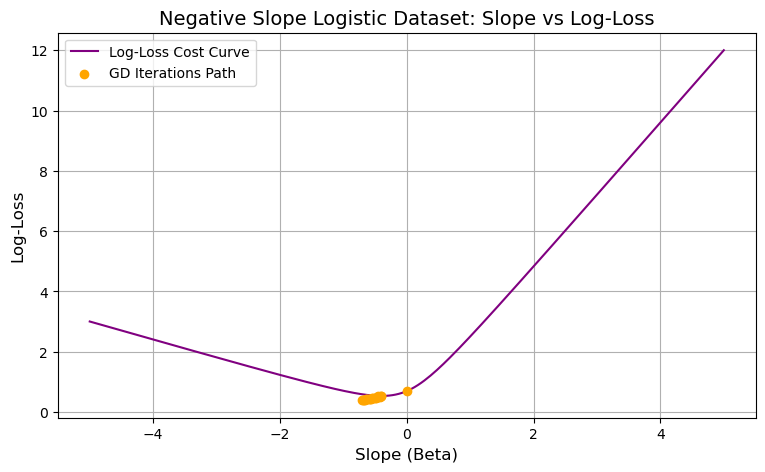

In [ ]:

x_pos = np.array([1, 2, 3, 4, 5], dtype=float)
y_pos = np.array([0, 0, 1, 1, 1], dtype=float)

x_neg = np.array([1, 2, 3, 4, 5], dtype=float)
y_neg = np.array([1, 1, 0, 0, 0], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_log_loss(y, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def gradient_descent_logistic(x, y, learning_rate=0.1, iterations=20, initial_beta=0.0):
    n = len(x)
    beta = initial_beta
    b = 0.0

    beta_history = []
    loss_history = []

    for i in range(iterations):
        z = beta * x + b
        y_pred = sigmoid(z)
        loss = compute_log_loss(y, y_pred)

        beta_history.append(beta)
        loss_history.append(loss)

        d_beta = (1/n) * np.sum((y_pred - y) * x)
        d_b = (1/n) * np.sum(y_pred - y)

        beta -= learning_rate * d_beta
        b -= learning_rate * d_b

    return beta, b, beta_history, loss_history

iterations = 20
lr = 0.5

beta_pos_final, b_pos_final, beta_pos_hist, loss_pos_hist = gradient_descent_logistic(x_pos, y_pos, lr, iterations, initial_beta=0.0)
beta_neg_final, b_neg_final, beta_neg_hist, loss_neg_hist = gradient_descent_logistic(x_neg, y_neg, lr, iterations, initial_beta=0.0)

print("Positive Slope Dataset Results")
print(f"Final Beta (Slope): {beta_pos_final:.4f}, Final Intercept: {b_pos_final:.4f}")

print("\nNegative Slope Dataset Results")
print(f"Final Beta (Slope): {beta_neg_final:.4f}, Final Intercept: {b_neg_final:.4f}")

print("\nIteration Progress Comparison (Beta Values)")
print(f"{'Iteration':<10}  {'Positive Slope Beta':<20}  {'Negative Slope Beta':<20}")
print("------------------------------------------------------------------")
for idx in [0, 4, 9, 14, 19]:
    print(f"{idx+1:<10}  {beta_pos_hist[idx]:<20.4f}  {beta_neg_hist[idx]:<20.4f}")

slope_range = np.linspace(-5, 5, 200)

def compute_loss_curve(x, y, slopes):
    loss_curve = []
    for s in slopes:
        preds = sigmoid(s * x)
        loss_curve.append(compute_log_loss(y, preds))
    return loss_curve

loss_curve_pos = compute_loss_curve(x_pos, y_pos, slope_range)
loss_curve_neg = compute_loss_curve(x_neg, y_neg, slope_range)

plt.figure(figsize=(9, 5))
plt.plot(slope_range, loss_curve_pos, color='blue', label='Log-Loss Cost Curve')
plt.scatter(beta_pos_hist, loss_pos_hist, color='red', zorder=5, label='GD Iterations Path')
plt.xlabel("Slope (Beta)", fontsize=12)
plt.ylabel("Log-Loss", fontsize=12)
plt.title("Positive Slope Logistic Dataset: Slope vs Log-Loss", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(slope_range, loss_curve_neg, color='purple', label='Log-Loss Cost Curve')
plt.scatter(beta_neg_hist, loss_neg_hist, color='orange', zorder=5, label='GD Iterations Path')
plt.xlabel("Slope (Beta)", fontsize=12)
plt.ylabel("Log-Loss", fontsize=12)
plt.title("Negative Slope Logistic Dataset: Slope vs Log-Loss", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

EXTRA QUESTIONS
Q5 AND Q6

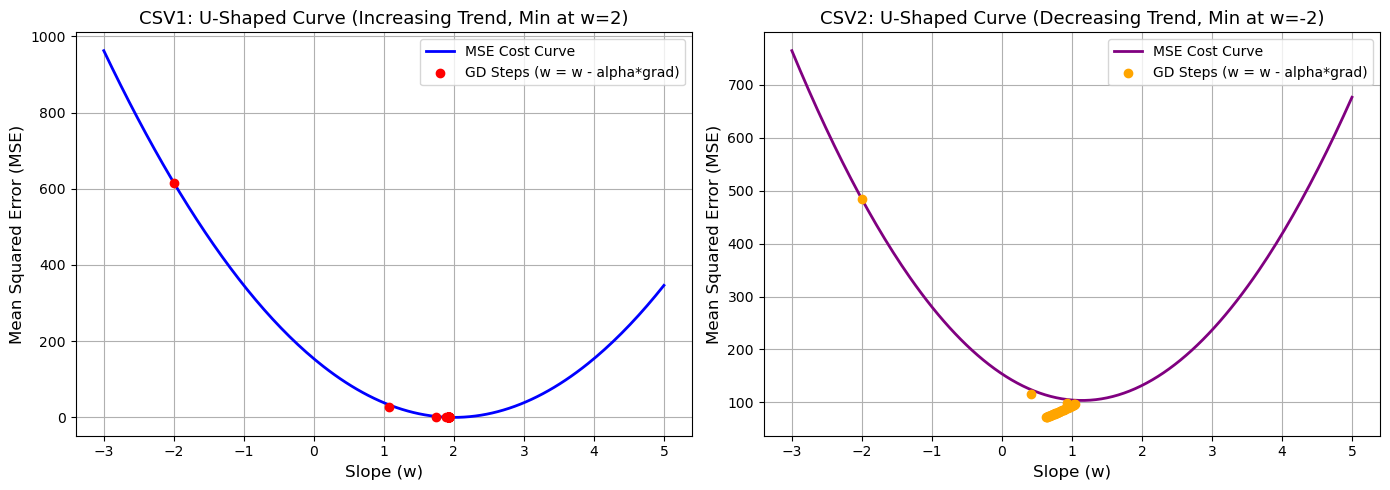

In [ ]:

x1 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y1 = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20], dtype=float)
pd.DataFrame({"x": x1, "y": y1}).to_csv("csv1.csv", index=False)
x2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y2 = np.array([20, 18, 16, 14, 12, 10, 8, 6, 4, 2], dtype=float)
pd.DataFrame({"x": x2, "y": y2}).to_csv("csv2.csv", index=False)
def run_gradient_descent(filename, alpha=0.01, iterations=40):
    data = pd.read_csv(filename)
    x = data["x"].values
    y = data["y"].values
    n = len(x)

    w = -2.0
    b = 0.0
    w_history = []
    mse_history = []
    for _ in range(iterations):
        y_pred = w * x + b
        mse = np.mean((y - y_pred) ** 2)
        w_history.append(w)
        mse_history.append(mse)
        grad_w = (-2 / n) * np.sum(x * (y - y_pred))
        grad_b = (-2 / n) * np.sum(y - y_pred)
        w = w - alpha * grad_w
        b = b - alpha * grad_b

    return w_history, mse_history, x, y

w_hist1, mse_hist1, x1_data, y1_data = run_gradient_descent("csv1.csv")
w_hist2, mse_hist2, x2_data, y2_data = run_gradient_descent("csv2.csv")
weight_range = np.linspace(-3, 5, 200)
def get_cost_curve(x, y, weights):
    return [np.mean((y - (w * x)) ** 2) for w in weights]
cost_curve1 = get_cost_curve(x1_data, y1_data, weight_range)
cost_curve2 = get_cost_curve(x2_data, y2_data, weight_range)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(weight_range, cost_curve1, color='blue', linewidth=2, label='MSE Cost Curve')
plt.scatter(w_hist1, mse_hist1, color='red', zorder=5, label='GD Steps (w = w - alpha*grad)')
plt.xlabel("Slope (w)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("CSV1: U-Shaped Curve (Increasing Trend, Min at w=2)", fontsize=13)
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(weight_range, cost_curve2, color='purple', linewidth=2, label='MSE Cost Curve')
plt.scatter(w_hist2, mse_hist2, color='orange', zorder=5, label='GD Steps (w = w - alpha*grad)')
plt.xlabel("Slope (w)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.title("CSV2: U-Shaped Curve (Decreasing Trend, Min at w=-2)", fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Additional Questions


1.Apply scikit learn model for Simple Linear regression using SGD of the given Salary_Data.csv
dataset, and arrive at different values of B0, B1 and error for varying iterations. Plot the graph of
epoch(X-axis) versus error(Y-axis).


Epochs: 1  B0 (Intercept): 3.6895  B1 (Coef): 9.7251 Error: 553.6916
Epochs: 5  B0 (Intercept): 7.1571  B1 (Coef): 16.1963 Error: 79.7727
Epochs: 10  B0 (Intercept): 8.4464  B1 (Coef): 16.0917 Error: 72.2910
Epochs: 20  B0 (Intercept): 10.5740  B1 (Coef): 15.2411 Error: 62.2628
Epochs: 50  B0 (Intercept): 15.7407  B1 (Coef): 13.4152 Error: 42.6081


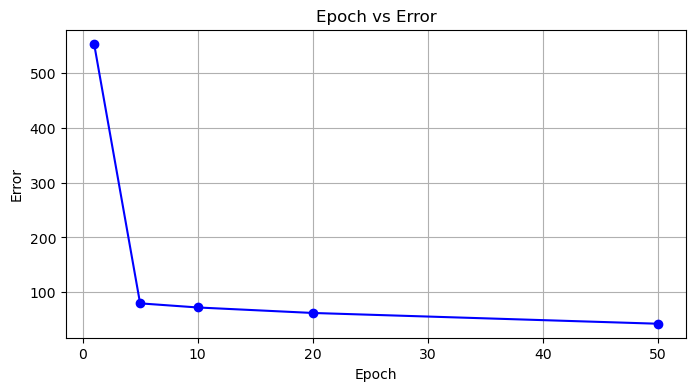

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
salary_data = {'Experience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.7, 3.9], 'Salary': [39.34, 46.20, 37.73, 43.55, 39.89, 56.64, 60.15, 64.44, 57.19, 63.21]}
df = pd.DataFrame(salary_data)
df.to_csv('Salary_Data.csv', index=False)
data = pd.read_csv('Salary_Data.csv')
X_skl = data['Experience'].values.reshape(-1, 1)
y_skl = data['Salary'].values
epoch_list = [1, 5, 10, 20, 50]
errors = []
for ep in epoch_list:
    model = SGDRegressor(max_iter=ep, tol=None, learning_rate='constant', eta0=0.01, random_state=42)
    model.fit(X_skl, y_skl)
    preds = model.predict(X_skl)
    err = mean_squared_error(y_skl, preds)
    errors.append(err)
    print(f"Epochs: {ep}  B0 (Intercept): {model.intercept_[0]:.4f}  B1 (Coef): {model.coef_[0]:.4f} Error: {err:.4f}")
plt.figure(figsize=(8, 4))
plt.plot(epoch_list, errors, marker='o', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Epoch vs Error")
plt.grid(True)
plt.show()


4.Consider positive and negative slope dataset given below. Apply logistic regression with gradient descent and
illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope(x-
axis) vs log-loss (y-axis) for both case separately.
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1]) # Positive slope
x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 1, 0, 0, 0]) # Negative slope


Manual First Epoch
Itern 1: w=0.0000, b=0.0000, MSE=9.6000, grad_w=-20.0000
Itern 2: w=0.2000, b=0.0560, MSE=5.7967, grad_w=-15.2640
Itern 3: w=0.3526, b=0.0989, MSE=3.5804, grad_w=-11.6486
Itern 4: w=0.4691, b=0.1317, MSE=2.2888, grad_w=-8.8888
Itern 5: w=0.5580, b=0.1570, MSE=1.5361, grad_w=-6.7819


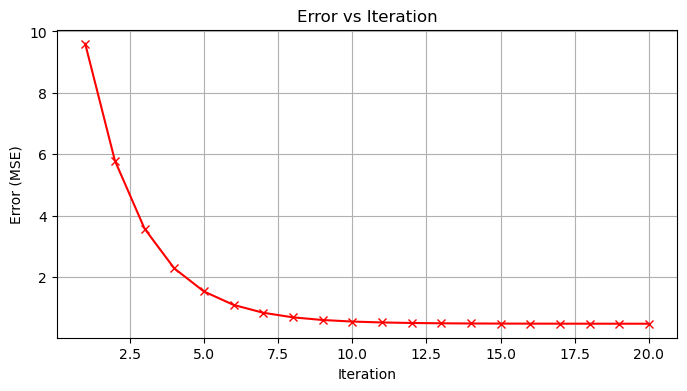

In [ ]:
x = np.array([1, 2, 4, 3, 5], dtype=float)
y = np.array([1, 3, 3, 2, 5], dtype=float)
w = 0.0
b = 0.0
alpha = 0.01
n = len(x)
iteration_errors = []
print("\nManual First Epoch")
for i in range(5):
    y_pred = w * x + b
    err = np.mean((y - y_pred) ** 2)
    dw = (-2/n) * np.sum(x * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    print(f"Itern {i+1}: w={w:.4f}, b={b:.4f}, MSE={err:.4f}, grad_w={dw:.4f}")
    w = w - alpha * dw
    b = b - alpha * db
total_epochs = 4
iterations_per_epoch = 5
total_iters = total_epochs * iterations_per_epoch
w_full = 0.0
b_full = 0.0
full_errors = []
for i in range(total_iters):
    y_pred = w_full * x + b_full
    err = np.mean((y - y_pred) ** 2)
    full_errors.append(err)
    dw = (-2/n) * np.sum(x * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    w_full = w_full - alpha * dw
    b_full = b_full - alpha * db
plt.figure(figsize=(8, 4))
plt.plot(range(1, total_iters + 1), full_errors, marker='x', color='red')
plt.xlabel("Iteration")
plt.ylabel("Error (MSE)")
plt.title("Error vs Iteration")
plt.grid(True)
plt.show()